In [3]:
import pandas as pd
from keras.saving import load_model
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('C:\\Users\\meerh\\OneDrive\\Documentos\\Projetos\\esp32-fall-detection\\data\\processed\\acc_gyr.csv')
df.shape

(96800, 7)

In [4]:
SEED = 42
MODELS_BASE_PATH = 'C:\\Users\\meerh\\OneDrive\\Documentos\\Projetos\\esp32-fall-detection\\models\\'

In [5]:
X = df.drop('label', axis=1)
y = df['label']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=SEED, stratify=y_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

((67760, 6), (67760,), (14520, 6), (14520,), (14520, 6), (14520,))

In [7]:
model_1 = load_model(MODELS_BASE_PATH + 'best_model_exp1.keras')
model_2 = load_model(MODELS_BASE_PATH + 'best_model_exp2.keras')
model_3 = load_model(MODELS_BASE_PATH + 'best_model_exp3.keras')

In [44]:
model_1_results = model_1.evaluate(X_test, y_test)
model_1_results

454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7953 - f1_score: 0.4487 - loss: 0.0142 - precision: 0.6185 - recall: 0.7631


[0.014248045161366463,
 0.7953168153762817,
 0.6184870600700378,
 0.7630952596664429,
 array([0.4487179], dtype=float32)]

In [45]:
model_2_results = model_2.evaluate(X_test, y_test)
model_2_results

454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7921 - f1_score: 0.4487 - loss: 0.0147 - precision: 0.6150 - recall: 0.7517


[0.014738666824996471,
 0.7920798659324646,
 0.6150399446487427,
 0.7516666650772095,
 array([0.4487179], dtype=float32)]

In [46]:
model_3_results = model_3.evaluate(X_test, y_test)
model_3_results

454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7795 - f1_score: 0.4487 - loss: 0.0158 - precision: 0.5949 - recall: 0.7457


[0.0158045943826437,
 0.7795454263687134,
 0.5948718190193176,
 0.7457143068313599,
 array([0.4487179], dtype=float32)]

In [49]:
results = model_1_results[1:4]
results.extend([model_1_results[-1].item()])
model_1_results = results

results = model_2_results[1:4]
results.extend([model_2_results[-1].item()])
model_2_results = results

results = model_3_results[1:4]
results.extend([model_3_results[-1].item()])
model_3_results = results

resultados = {
    "Model 1": model_1_results,
    "Model 2": model_2_results,
    "Model 3": model_3_results
}
resultados

{'Model 1': [0.7953168153762817,
  0.6184870600700378,
  0.7630952596664429,
  0.4487178921699524],
 'Model 2': [0.7920798659324646,
  0.6150399446487427,
  0.7516666650772095,
  0.4487178921699524],
 'Model 3': [0.7795454263687134,
  0.5948718190193176,
  0.7457143068313599,
  0.4487178921699524]}

In [50]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparacao_modelos(resultados_modelos):
    metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
    nomes_modelos = list(resultados_modelos.keys())
    
    # Certifique-se de que há exatamente 3 modelos para esta visualização
    if len(nomes_modelos) != 3:
        raise ValueError("O dicionário deve conter exatamente 3 modelos.")

    # Extrai as listas de valores para cada modelo
    valores_mod1 = resultados_modelos[nomes_modelos[0]]
    valores_mod2 = resultados_modelos[nomes_modelos[1]]
    valores_mod3 = resultados_modelos[nomes_modelos[2]]

    # Define as posições base no eixo X (uma para cada métrica)
    x = np.arange(len(metricas))
    
    # Define a largura das barras (dividimos o espaço para caber as 3 barras juntas)
    largura = 0.25

    # Configuração da figura
    fig, ax = plt.subplots(figsize=(10, 6))

    # Cria as barras deslocando as posições no eixo X (-largura, 0, +largura)
    barras1 = ax.bar(x - largura, valores_mod1, largura, label=nomes_modelos[0], color='#4C72B0')
    barras2 = ax.bar(x,           valores_mod2, largura, label=nomes_modelos[1], color='#DD8452')
    barras3 = ax.bar(x + largura, valores_mod3, largura, label=nomes_modelos[2], color='#55A868')

    # Personaliza textos, títulos e eixos
    ax.set_ylabel('Pontuação', fontsize=12)
    ax.set_title('Comparação de Métricas de Avaliação entre Modelos', fontsize=14, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(metricas, fontsize=11)
    
    # Posiciona a legenda fora do gráfico para não sobrepor as barras
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)

    # Aumenta o limite do eixo Y para sobrar espaço para os números em cima das barras
    ax.set_ylim(0, 1.15)

    # Função auxiliar para adicionar o valor acima de cada barra
    def adicionar_rotulos(barras):
        for barra in barras:
            altura = barra.get_height()
            ax.annotate(f'{altura:.3f}', # Formata com 3 casas decimais
                        xy=(barra.get_x() + barra.get_width() / 2, altura),
                        xytext=(0, 3),   # Deslocamento de 3 pontos para cima
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)

    # Aplica a função de rótulos nas três barras
    adicionar_rotulos(barras1)
    adicionar_rotulos(barras2)
    adicionar_rotulos(barras3)

    # Adiciona uma grade horizontal sutil
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Ajusta o layout e plota
    plt.tight_layout()
    plt.show()

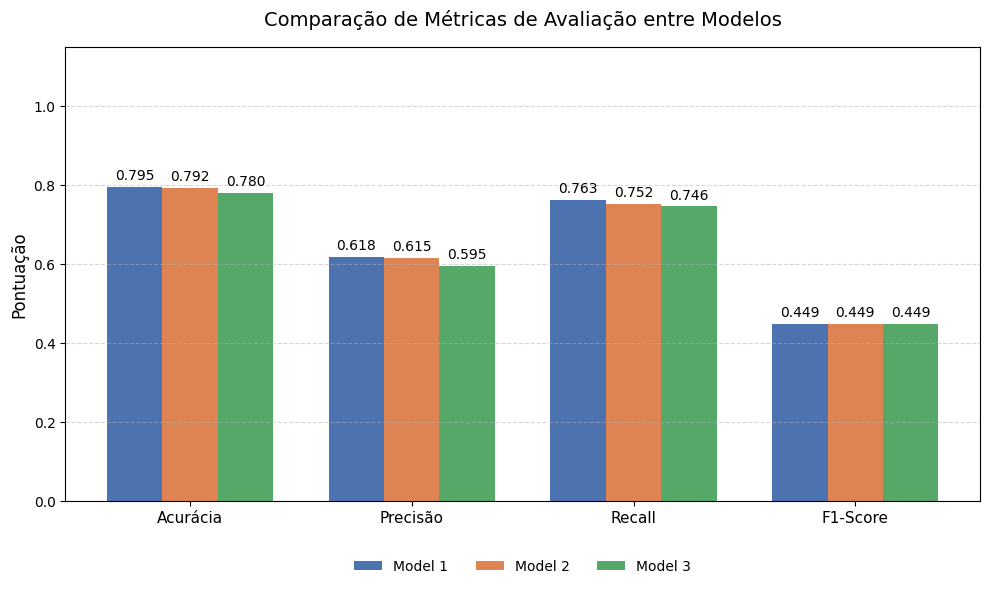

In [51]:
plot_comparacao_modelos(resultados)